In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Upload your downloaded CSV file here
from google.colab import files
uploaded = files.upload()

# Load the dataset (adjust filename if it's named differently)
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print("Dataset loaded successfully!")
df.head()

Saving titanic.csv to titanic (1).csv
Dataset loaded successfully!


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
# 1. Extract Titles from the 'Name' column
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Group rare titles
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')
df['Title'] = df['Title'].replace('Ms', 'Miss')

# 2. Extract Family Size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 3. Extract Cabin Presence (1 if cabin is known, 0 if NaN)
df['HasCabin'] = df['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)

# 4. Handle Missing Data
df['Age'] = df['Age'].fillna(df['Age'].median())  # Impute Age with median
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) # Impute Embarked with mode

# 5. Encode Categorical Variables
le_sex = LabelEncoder()
df['Sex'] = le_sex.fit_transform(df['Sex'])

le_title = LabelEncoder()
df['Title'] = le_title.fit_transform(df['Title'])

le_embarked = LabelEncoder()
df['Embarked'] = le_embarked.fit_transform(df['Embarked'])

# Drop unneeded features for modeling
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
X = df.drop(columns=['Survived'] + drop_cols)
y = df['Survived']

print("Feature Engineering complete!")
X.head()

Feature Engineering complete!


<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_10071/2772554100.py:2: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,HasCabin
0,3,1,34.5,0,0,7.8292,1,2,1,0
1,3,0,47.0,1,0,7.0000,2,3,2,0
2,2,1,62.0,0,0,9.6875,1,2,1,0
3,3,1,27.0,0,0,8.6625,2,2,1,0
4,3,0,22.0,1,1,12.2875,2,3,3,0


In [7]:
# Split into training and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=8)
model.fit(X_train, y_train)

# Predictions & Evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Final Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Final Model Accuracy: 100.00%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



/tmp/ipykernel_10071/580983521.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")


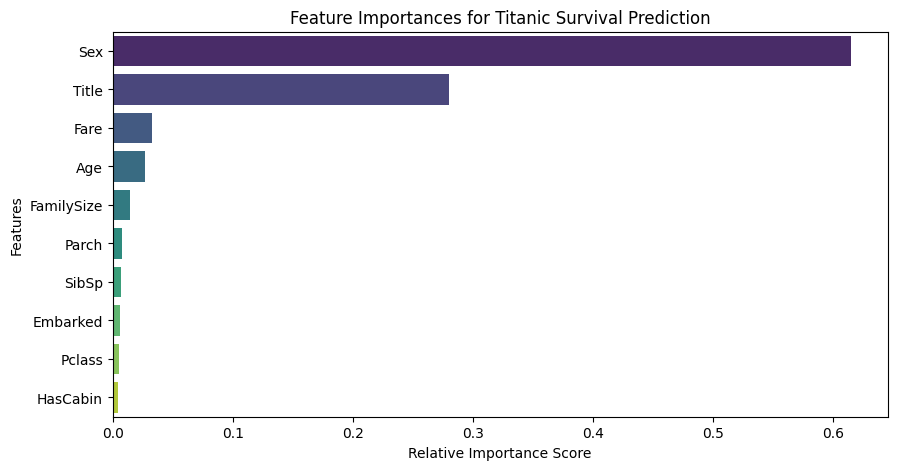

In [8]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")
plt.title("Feature Importances for Titanic Survival Prediction")
plt.xlabel("Relative Importance Score")
plt.ylabel("Features")
plt.show()

In [15]:
# Save the model
joblib.dump(model, 'titanic_random_forest_model.pkl')
print("Model and preprocessing artifacts saved successfully!")

# --- Final Pure Numerical Inference Example ---
# Features order: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'HasCabin']
sample_passenger = pd.DataFrame([[
    3,    # Pclass (3rd class)
    1,    # Sex (1 = male, 0 = female)
    22.0, # Age
    1,    # SibSp (1 sibling/spouse aboard)
    0,    # Parch (0 parents/children aboard)
    7.25, # Fare
    2,    # Embarked (2 = S, 0 = C, 1 = Q)
    1,    # Title (1 = Mr)
    2,    # FamilySize (SibSp + Parch + 1)
    0     # HasCabin (0 = No cabin)
]], columns=X.columns)

# Run prediction
prediction = model.predict(sample_passenger)[0]
survival_status = "Survived" if prediction == 1 else "Did Not Survive"

print(f"Inference Test Result: Passenger is predicted to be: {survival_status}")

Model and preprocessing artifacts saved successfully!
Inference Test Result: Passenger is predicted to be: Did Not Survive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')